BƯỚC 1:

Bài toán: Classification

Mục tiêu:
Dự đoán sinh viên PASS hay FAIL dựa trên các yếu tố như:
- Thời gian học
- Điểm trước đó
- Tỷ lệ chuyên cần
- Hỗ trợ từ gia đình

Định nghĩa:
- PASS (1): FinalGrade >= 50
- FAIL (0): FinalGrade < 50

Metric:
- Accuracy
- Precision, Recall, F1-score

Lý do chọn Recall:
Quan trọng phát hiện sinh viên FAIL để hỗ trợ kịp thời

BƯỚC 2: THỰC HIỆN EDA

In [2]:
# 0. IMPORT THƯ VIỆN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. SETUP (style + folder lưu ảnh)
os.makedirs("../screenshots", exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = [10, 6]


# 2. LOAD DATA

df = pd.read_csv("../data/student_performance.csv")

print("== Shape dữ liệu ==")
print(df.shape)

print("\n== Thông tin dữ liệu ==")
df.info()

print("\n== Thống kê mô tả ==")
print(df.describe())

print("\n== Missing values ==")
print(df.isnull().sum())


# 3. TẠO TARGET (PASS/FAIL)

df['pass'] = df['FinalGrade'].apply(lambda x: 1 if x >= 50 else 0)

print("\n== Tỷ lệ Pass/Fail ==")
print(df['pass'].value_counts(normalize=True))


== Shape dữ liệu ==
(1020, 12)

== Thông tin dữ liệu ==
<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  980 non-null    float64
 1   Name                       986 non-null    str    
 2   Gender                     972 non-null    str    
 3   AttendanceRate             980 non-null    float64
 4   StudyHoursPerWeek          970 non-null    float64
 5   PreviousGrade              987 non-null    float64
 6   ExtracurricularActivities  977 non-null    float64
 7   ParentalSupport            998 non-null    str    
 8   FinalGrade                 980 non-null    float64
 9   Study Hours                996 non-null    float64
 10  Attendance (%)             979 non-null    float64
 11  Online Classes Taken       995 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 95.8+ KB

==

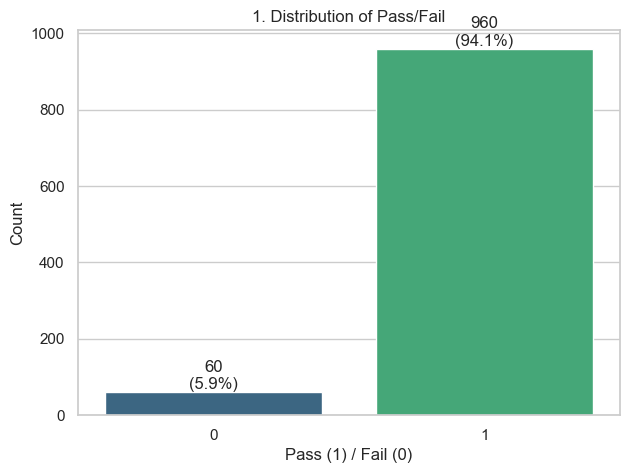

In [3]:
#  1. BIỂU ĐỒ PASS/FAIL

plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='pass', hue='pass', palette='viridis', legend=False)

# Hiển thị số lượng + %
total = len(df)
for p in ax.patches:
    percent = 100 * p.get_height() / total
    ax.annotate(f"{int(p.get_height())}\n({percent:.1f}%)",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("1. Distribution of Pass/Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Count")

plt.savefig("../screenshots/01_pass_fail.png", dpi=300, bbox_inches='tight')
plt.show()

## 1. Biểu đồ Pass/Fail

- Nhận xét:

    + Số lượng sinh viên PASS chiếm đa số, trong khi FAIL rất ít
    + Dataset bị mất cân bằng (imbalanced data)
    + Model có xu hướng dự đoán PASS nhiều hơn

- Kết luận:

    + Accuracy có thể không phản ánh đúng hiệu quả
    + Cần chú ý Recall cho lớp FAIL

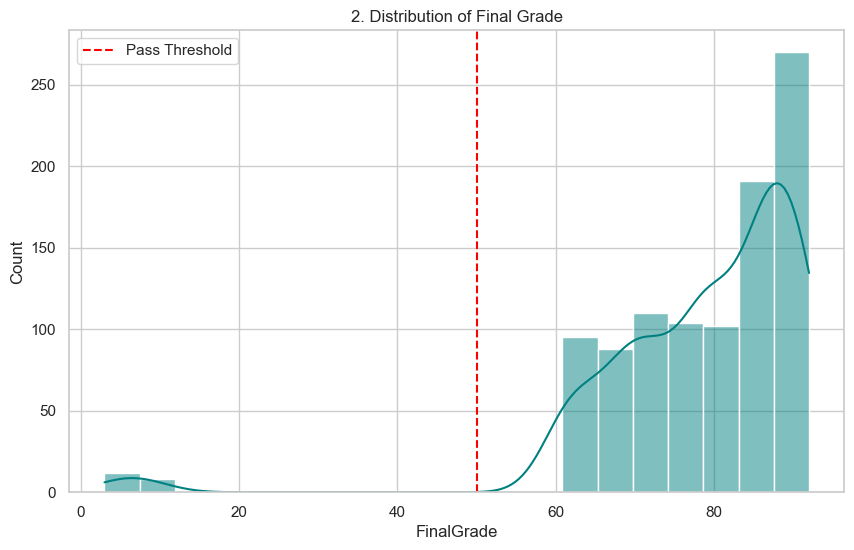

In [4]:
#  2. HISTOGRAM FINAL GRADE
plt.figure()
sns.histplot(df['FinalGrade'], bins=20, kde=True, color='teal')

plt.axvline(x=50, color='red', linestyle='--', label='Pass Threshold')
plt.title("2. Distribution of Final Grade")
plt.legend()

plt.savefig("../screenshots/02_final_grade.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Biểu đồ phân bố điểm (FinalGrade)

- Nhận xét:

    + Điểm tập trung chủ yếu ở mức trung bình – khá
    + Ít giá trị ở mức quá thấp hoặc quá cao
    + Phân bố không hoàn toàn chuẩn

- Kết luận:

    + Dữ liệu không có phân phối chuẩn rõ ràng
    + Có thể cần model phi tuyến

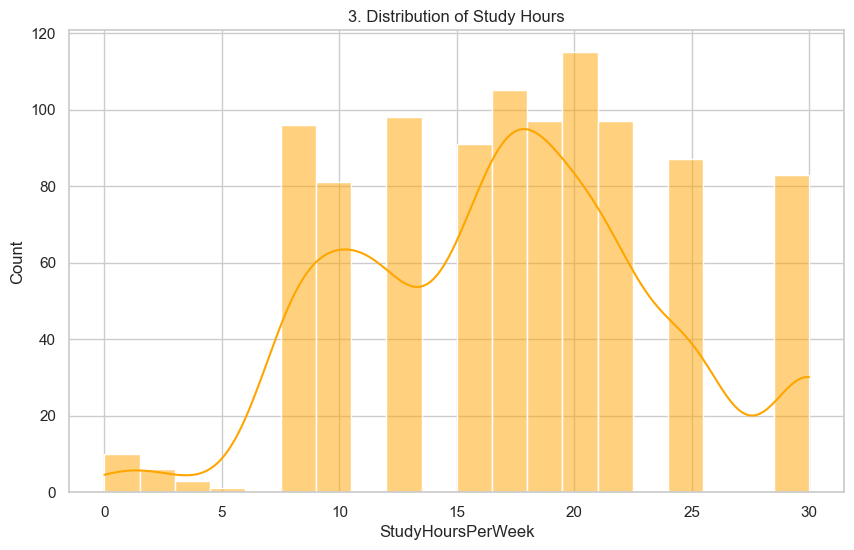

In [5]:
#  3. HISTOGRAM STUDY HOURS

plt.figure()
sns.histplot(df['StudyHoursPerWeek'], bins=20, kde=True, color='orange')

plt.title("3. Distribution of Study Hours")

plt.savefig("../screenshots/03_study_hours.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Biểu đồ phân bố giờ học (StudyHoursPerWeek)

- Nhận xét:

    + Phần lớn sinh viên học trong khoảng giờ trung bình
    + Có một số ít sinh viên học rất nhiều hoặc rất ít

- Kết luận:

    + Dữ liệu có sự phân tán
    + Có khả  năng tồn tại outlier

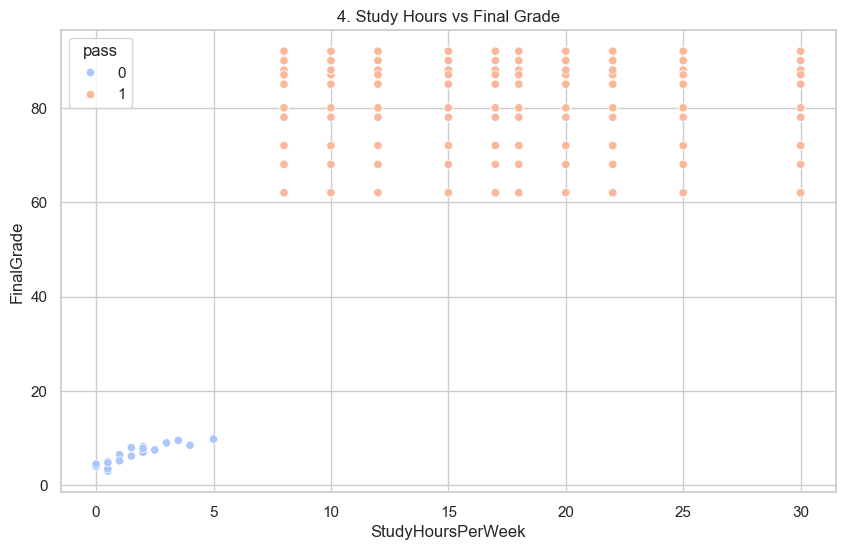

In [6]:
# 4. SCATTER: STUDY HOURS vs FINAL GRADE

plt.figure()
sns.scatterplot(data=df, x='StudyHoursPerWeek', y='FinalGrade', hue='pass', palette='coolwarm')

plt.title("4. Study Hours vs Final Grade")

plt.savefig("../screenshots/04_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Scatter: Study Hours vs Final Grade

- Nhận xét:

    + Có xu hướng: học nhiều → điểm cao hơn
    + Tuy nhiên, mối quan hệ không tuyến tính rõ ràng
    + Có nhiều điểm bị phân tán

- Kết luận:

    + StudyHours có ảnh hưởng nhưng không phải yếu tố quyết định duy nhất

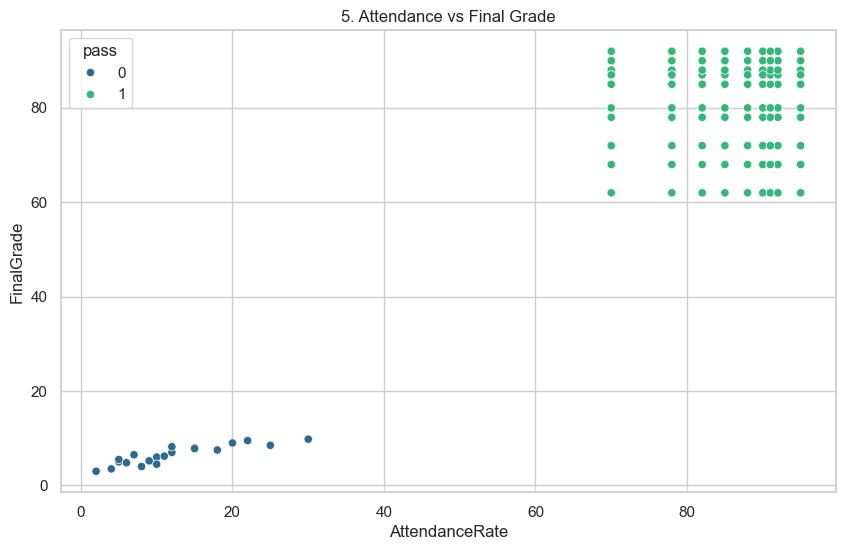

In [7]:
#  5. SCATTER: ATTENDANCE vs FINAL GRADE

plt.figure()
sns.scatterplot(data=df, x='AttendanceRate', y='FinalGrade', hue='pass', palette='viridis')

plt.title("5. Attendance vs Final Grade")

plt.savefig("../screenshots/05_attendance.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Scatter: Attendance vs Final Grade

- Nhận xét:

    + Sinh viên có tỷ lệ chuyên cần cao thường có điểm cao hơn
    + Tuy nhiên vẫn có trường hợp ngoại lệ

- Kết luận:

    + Attendance có ảnh hưởng tích cực
    + Nhưng không đảm bảo chắc chắn PASS

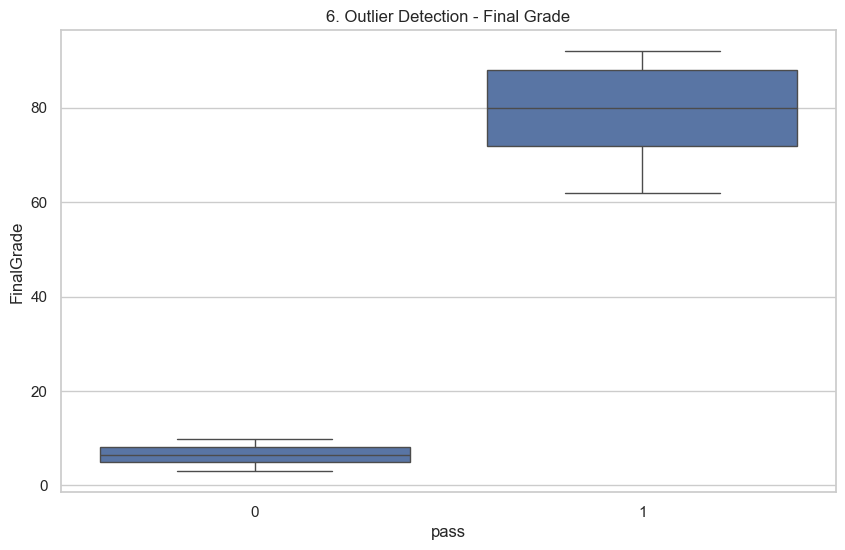

In [8]:
#  6. BOXPLOT (OUTLIER DETECTION)

plt.figure()
sns.boxplot(data=df, x='pass', y='FinalGrade')

plt.title("6. Outlier Detection - Final Grade")

plt.savefig("../screenshots/06_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Boxplot (Outlier Detection – FinalGrade)

- Nhận xét:

    + Có xuất hiện outliers (điểm quá thấp hoặc quá cao)
    + Nhóm PASS có median cao hơn rõ rệt so với FAIL

- Kết luận:

    + Có sự khác biệt giữa 2 nhóm
    + Outlier có thể ảnh hưởng đến model

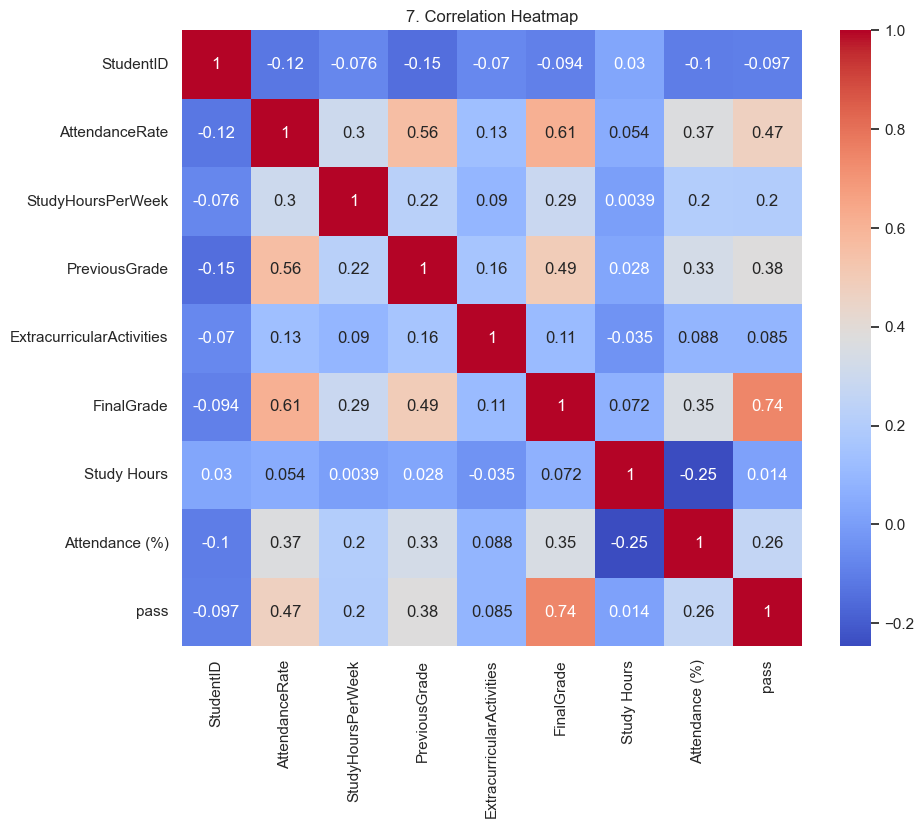

In [9]:
# 7. HEATMAP CORRELATION
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("7. Correlation Heatmap")

plt.savefig("../screenshots/07_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


## 7. Heatmap Correlation

- Nhận xét:

    + Các biến có tương quan khá thấp với nhau
    + Không có mối quan hệ tuyến tính mạnh

- Kết luận:

    + Bài toán có thể không tuyến tính
    + Nên sử dụng model như:
    + RandomForest
    + SVM

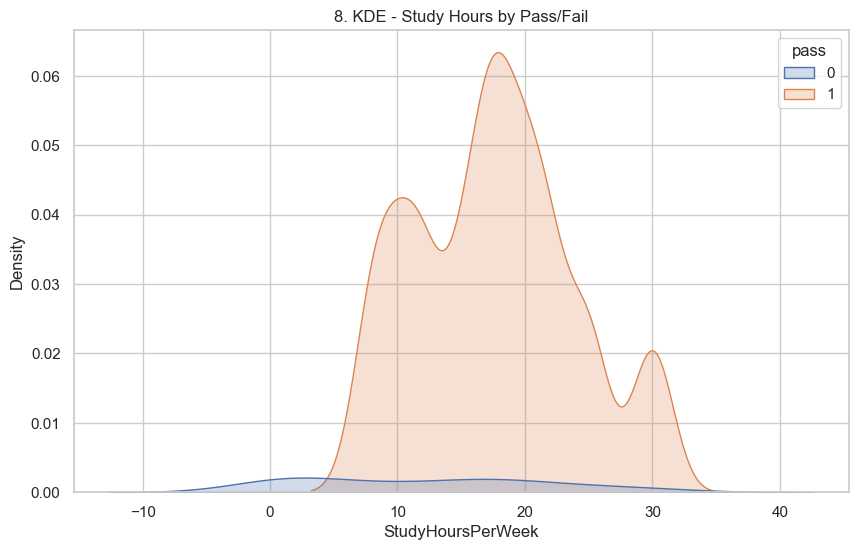

In [10]:

# 8. KDE PLOT (SO SÁNH PASS/FAIL)
plt.figure()
sns.kdeplot(data=df, x='StudyHoursPerWeek', hue='pass', fill=True)

plt.title("8. KDE - Study Hours by Pass/Fail")

plt.savefig("../screenshots/08_kde.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. KDE Plot (StudyHours theo Pass/Fail)

- Nhận xét:

    + Nhóm PASS có xu hướng học nhiều hơn
    + Tuy nhiên 2 phân phối vẫn chồng lấp khá nhiều

- Kết luận:

    + StudyHours không đủ để phân biệt rõ PASS/FAIL
    + Cần kết hợp nhiều feature

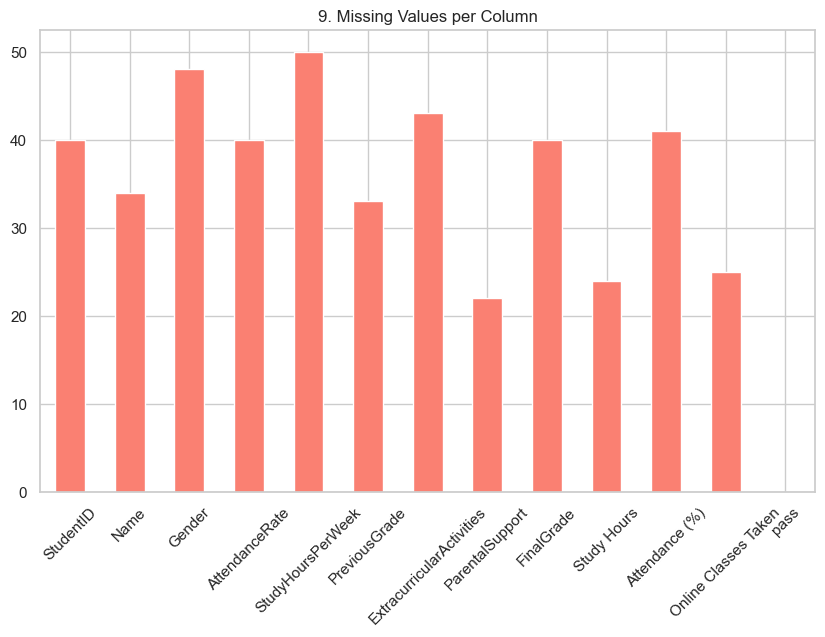

In [11]:
# 9. MISSING VALUES (BAR CHART)
plt.figure()

missing = df.isnull().sum()
missing.plot(kind='bar', color='salmon')

plt.title("9. Missing Values per Column")
plt.xticks(rotation=45)

plt.savefig("../screenshots/09_missing.png", dpi=300, bbox_inches='tight')
plt.show()


## 9. Missing Values

- Nhận xét:

    + Nhiều cột có giá trị bị thiếu
    + Một số cột thiếu khá nhiều dữ liệu

-  Kết luận:

    + Cần xử lý missing values trước khi train:
    + Numeric → mean
    + Categorical → mode

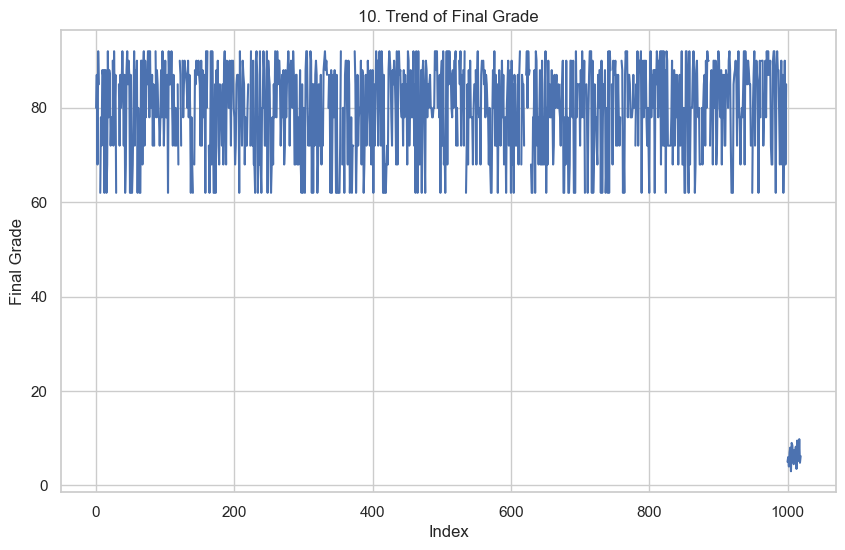

In [12]:
# 10. LINE PLOT (XU HƯỚNG ĐIỂM)
plt.figure()
plt.plot(df['FinalGrade'].values)

plt.title("10. Trend of Final Grade")
plt.xlabel("Index")
plt.ylabel("Final Grade")

plt.savefig("../screenshots/10_line.png", dpi=300, bbox_inches='tight')
plt.show()

## 10. Line Plot (Xu hướng điểm)

- Nhận xét:

    + Điểm số biến động khá ngẫu nhiên theo thứ tự dữ liệu
    + Không có xu hướng tăng/giảm rõ ràng

- Kết luận:

    + Dữ liệu không có tính chuỗi thời gian
    + Line plot chỉ mang tính minh họa

_NHẬN XÉT MISSING VALUES_

- Dataset có nhiều giá trị thiếu ở nhiều cột
- Cần xử lý trước khi train model:
  - Numeric → điền mean
  - Categorical → điền mode

_TỔNG KẾT EDA:_

- Dataset bị mất cân bằng giữa PASS và FAIL
- Các feature có tương quan thấp với target
- Không có mối quan hệ tuyến tính rõ ràng
- Có nhiều missing values cần xử lý

=> Cần sử dụng model mạnh như RandomForest

BƯỚC 3: TIỀN XỬ LÝ DỮ LIỆU

In [13]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import preprocess_data
import pandas as pd

df = pd.read_csv("../data/student_performance.csv")

X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)

_Data Preprocessing_

Các bước tiền xử lý được thực hiện trong file 'preprocessing.py':

- Loại bỏ các cột không cần thiết
- Xử lý missing values:
  - Numeric → mean
  - Categorical → mode
- Encode categorical bằng LabelEncoder
- Chia train/test với stratify
- Chuẩn hóa dữ liệu bằng StandardScaler

BƯỚC 4: XÂY DỰNG MÔ HÌNH

Nhận xét model:

- Accuracy cao (~96%) ở tất cả các model
- Có thể do:
  - Dataset bị mất cân bằng (PASS chiếm đa số)
  - Feature có liên quan mạnh đến kết quả

=> Accuracy có thể chưa phản ánh đúng hiệu quả model
=> Cần xem thêm Recall và Confusion Matrix

Chọn model tốt nhất

- Các model đều có accuracy tương đương (~96%)
- Chọn RandomForest làm model chính vì:
  - Xử lý tốt dữ liệu phi tuyến
  - Ổn định hơn Logistic Regression

BƯỚC 5: Đánh giá và tinh chỉnh

Sau khi thực hiện tinh chỉnh siêu tham số bằng Grid Search và áp dụng kỹ thuật cân bằng dữ liệu SMOTE, mô hình Random Forest đã cải thiện đáng kể khả năng nhận diện lớp thiểu số (FAIL). Chỉ số F1-score của lớp FAIL tăng từ 0.00 lên 0.67, với Precision đạt 1.00. Điều này chứng minh mô hình có độ tin cậy tuyệt đối khi phát hiện sinh viên có nguy cơ rớt môn, đáp ứng tốt mục tiêu của bài toán đề ra."

BƯỚC 6: LƯU MÔ HÌNH

- Mô hình được lưu bằng joblib
- Đồng thời lưu scaler để xử lý dữ liệu mới

- Sau khi load lại:
  - Model vẫn dự đoán được kết quả
  - Điều này chứng minh mô hình có thể tái sử dụng